# Test and Visualize SignalTrainLA2ADatasetSingle

Minimal notebook to test and visualize the `SignalTrainLA2ADatasetSingle` dataset class.

This dataset loads a single clip (by index) and splits it into segments of fixed length.

## Setup

In [5]:
import torch
import soundfile as sf
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import glob
import librosa
import librosa.display

In [6]:
# Dataset path - update to your SignalTrain LA2A root directory
ROOT_DIR = "/home/shreyan/Documents/DATASETS/SignalTrain_LA2A_Dataset_1.1"
SUBSET = "Train"
CLIP_IDX = 263  # Index of the clip to load
SEGMENT_LENGTH = 65536  # ~1.5 seconds at 44.1kHz
SAMPLE_RATE = 44100

## Dataset Class Definition

Note: Fixed version that properly handles glob pattern for target files.

In [9]:
class SignalTrainLA2ADatasetSingle(torch.utils.data.Dataset):
    """Dataset that loads a single clip and splits it into segments."""
    
    def __init__(
        self,
        root_dir: str,
        subset: str = "Train",
        clip_idx: int = 0,
        length: int = 65536,
        sample_rate: int = 44100,
    ):
        self.root_dir = Path(root_dir)
        self.subset = subset
        self.clip_idx = clip_idx
        self.length = length
        self.sample_rate = sample_rate

        self.subset_dir = self.root_dir / self.subset
        if not self.subset_dir.exists():
            raise FileNotFoundError(f"Subset directory not found: {self.subset_dir}")

        input_audio_path = self.subset_dir / f"input_{self.clip_idx}_.wav"
        
        # Find target file using glob pattern (fixes the original implementation)
        target_pattern = str(self.subset_dir / f"target_{self.clip_idx}_*.wav")
        target_matches = glob.glob(target_pattern)
        
        if not target_matches:
            raise FileNotFoundError(f"No target file found matching pattern: {target_pattern}")
        if len(target_matches) > 1:
            raise ValueError(f"Multiple target files found: {target_matches}")
        
        target_audio_path = Path(target_matches[0])

        if not input_audio_path.exists():
            raise FileNotFoundError(f"Input file not found: {input_audio_path}")

        # Load audio files
        input_audio = sf.read(str(input_audio_path), dtype="float32", always_2d=True)[0][:, 0]
        target_audio = sf.read(str(target_audio_path), dtype="float32", always_2d=True)[0][:, 0]

        # Ensure lengths of input and target are the same
        if len(input_audio) != len(target_audio):
            raise ValueError(
                f"Input and target audio lengths do not match: "
                f"{len(input_audio)} != {len(target_audio)}"
            )

        # Split into segments
        input_audio_segments = []
        target_audio_segments = []

        for i in range(0, len(input_audio), self.length):
            if i + self.length > len(input_audio):
                end_sample = len(input_audio)
            else:
                end_sample = i + self.length
            
            # Pad last segment if needed
            input_seg = input_audio[i:end_sample].copy()
            target_seg = target_audio[i:end_sample].copy()
            
            if len(input_seg) < self.length:
                # Pad with zeros
                input_seg = np.pad(input_seg, (0, self.length - len(input_seg)), mode='constant')
                target_seg = np.pad(target_seg, (0, self.length - len(target_seg)), mode='constant')
            
            input_audio_segments.append(torch.from_numpy(input_seg))
            target_audio_segments.append(torch.from_numpy(target_seg))

        self.input_audio_segments = input_audio_segments
        self.target_audio_segments = target_audio_segments
        self.input_audio_path = input_audio_path
        self.target_audio_path = target_audio_path

    def __len__(self):
        return len(self.input_audio_segments)

    def __getitem__(self, idx):
        return self.input_audio_segments[idx], self.target_audio_segments[idx]

## Create Dataset Instance

In [10]:
# Create dataset instance
dataset = SignalTrainLA2ADatasetSingle(
    root_dir=ROOT_DIR,
    subset=SUBSET,
    clip_idx=CLIP_IDX,
    length=SEGMENT_LENGTH,
    sample_rate=SAMPLE_RATE
)

print(f"Dataset created successfully!")
print(f"Number of segments: {len(dataset)}")
print(f"Segment length: {SEGMENT_LENGTH} samples ({SEGMENT_LENGTH/SAMPLE_RATE:.2f} seconds)")
print(f"Input file: {dataset.input_audio_path}")
print(f"Target file: {dataset.target_audio_path}")

Dataset created successfully!
Number of segments: 606
Segment length: 65536 samples (1.49 seconds)
Input file: /home/shreyan/Documents/DATASETS/SignalTrain_LA2A_Dataset_1.1/Train/input_263_.wav
Target file: /home/shreyan/Documents/DATASETS/SignalTrain_LA2A_Dataset_1.1/Train/target_263_LA2A_2c__1__100.wav


## Test Loading Samples

In [11]:
# Load a few samples
num_samples_to_test = min(3, len(dataset))

for idx in range(num_samples_to_test):
    input_seg, target_seg = dataset[idx]
    print(f"\nSegment {idx}:")
    print(f"  Input shape: {input_seg.shape}, dtype: {input_seg.dtype}")
    print(f"  Target shape: {target_seg.shape}, dtype: {target_seg.dtype}")
    print(f"  Input range: [{input_seg.min():.4f}, {input_seg.max():.4f}]")
    print(f"  Target range: [{target_seg.min():.4f}, {target_seg.max():.4f}]")
    print(f"  Input RMS: {torch.sqrt(torch.mean(input_seg**2)):.4f}")
    print(f"  Target RMS: {torch.sqrt(torch.mean(target_seg**2)):.4f}")


Segment 0:
  Input shape: torch.Size([65536]), dtype: torch.float32
  Target shape: torch.Size([65536]), dtype: torch.float32
  Input range: [-0.4344, 0.3022]
  Target range: [-0.1009, 0.1127]
  Input RMS: 0.0774
  Target RMS: 0.0143

Segment 1:
  Input shape: torch.Size([65536]), dtype: torch.float32
  Target shape: torch.Size([65536]), dtype: torch.float32
  Input range: [-0.2525, 0.2742]
  Target range: [-0.0407, 0.0408]
  Input RMS: 0.0632
  Target RMS: 0.0125

Segment 2:
  Input shape: torch.Size([65536]), dtype: torch.float32
  Target shape: torch.Size([65536]), dtype: torch.float32
  Input range: [-0.2933, 0.2602]
  Target range: [-0.0481, 0.0432]
  Input RMS: 0.0537
  Target RMS: 0.0120


## Visualize Waveforms

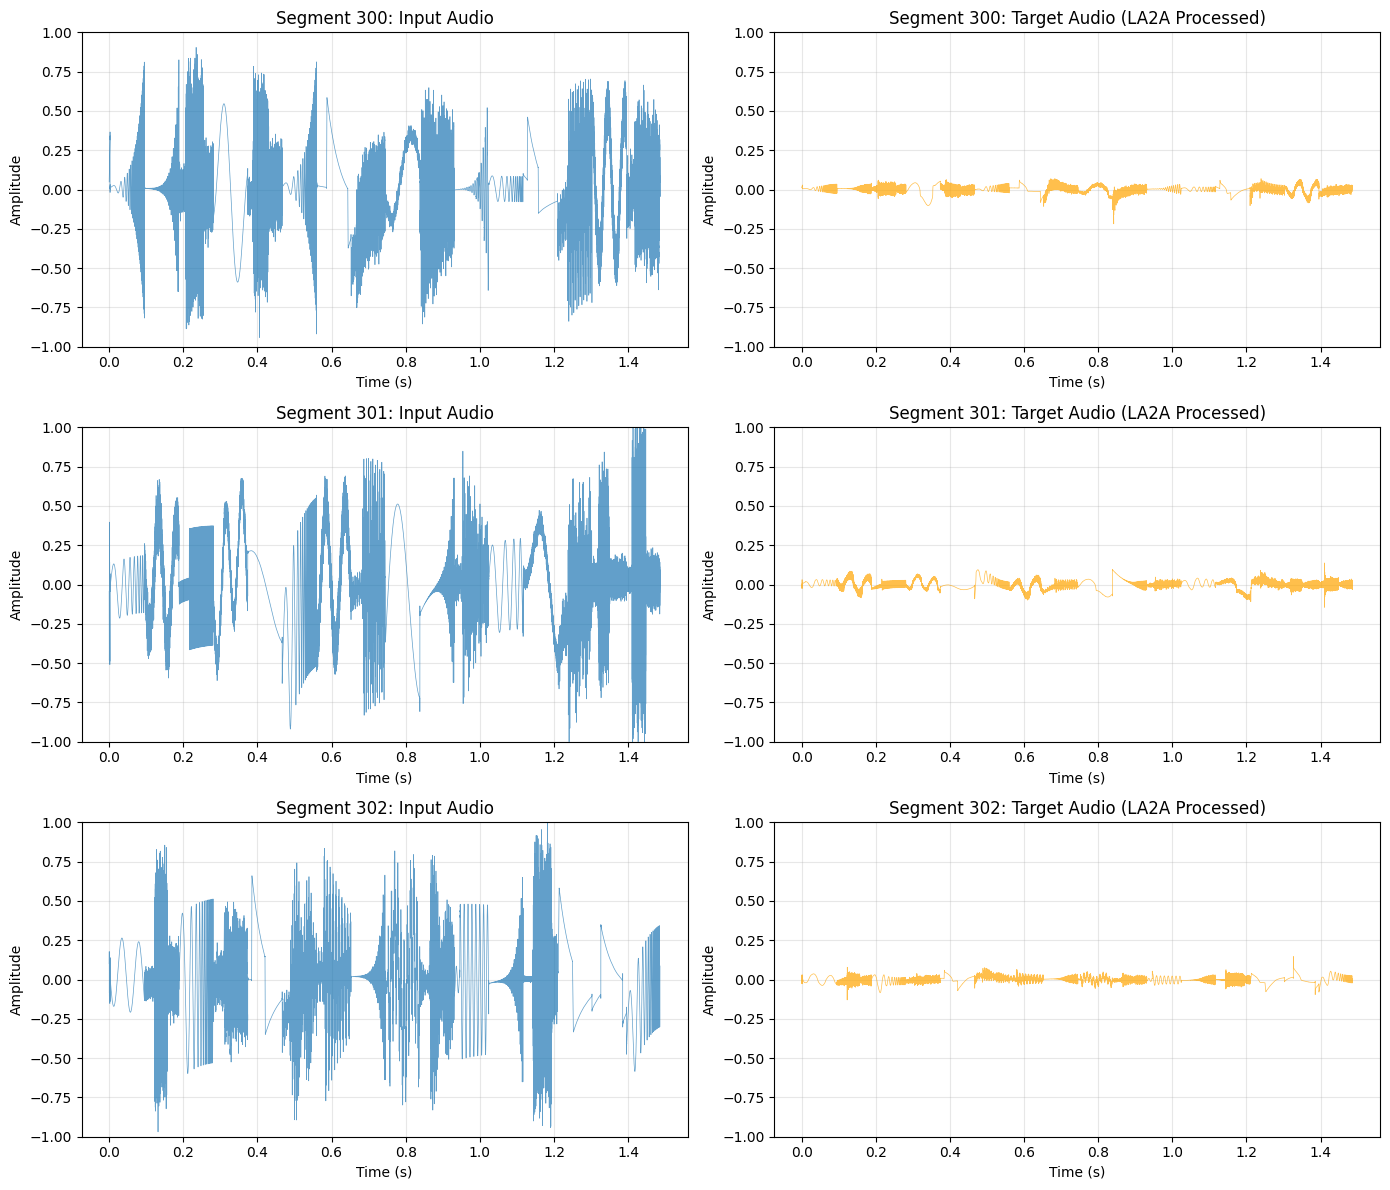

In [19]:
# Visualize first few segments
num_segments_to_plot = min(3, len(dataset))
fig, axes = plt.subplots(num_segments_to_plot, 2, figsize=(14, 4 * num_segments_to_plot))

if num_segments_to_plot == 1:
    axes = axes.reshape(1, -1)

for idx, seg_idx in enumerate(range(300, 300+num_segments_to_plot)):
    input_seg, target_seg = dataset[seg_idx]
    
    # Convert to numpy for plotting
    input_np = input_seg.numpy()
    target_np = target_seg.numpy()
    
    # Time axis in seconds
    time_axis = np.arange(len(input_np)) / SAMPLE_RATE
    
    # Plot input
    axes[idx, 0].plot(time_axis, input_np, alpha=0.7, linewidth=0.5)
    axes[idx, 0].set_title(f'Segment {seg_idx}: Input Audio')
    axes[idx, 0].set_xlabel('Time (s)')
    axes[idx, 0].set_ylabel('Amplitude')
    axes[idx, 0].grid(True, alpha=0.3)
    axes[idx, 0].set_ylim([-1, 1])
    
    # Plot target
    axes[idx, 1].plot(time_axis, target_np, alpha=0.7, linewidth=0.5, color='orange')
    axes[idx, 1].set_title(f'Segment {seg_idx}: Target Audio (LA2A Processed)')
    axes[idx, 1].set_xlabel('Time (s)')
    axes[idx, 1].set_ylabel('Amplitude')
    axes[idx, 1].grid(True, alpha=0.3)
    axes[idx, 1].set_ylim([-1, 1])

plt.tight_layout()
plt.show()

## Compare Input vs Target (Overlay)

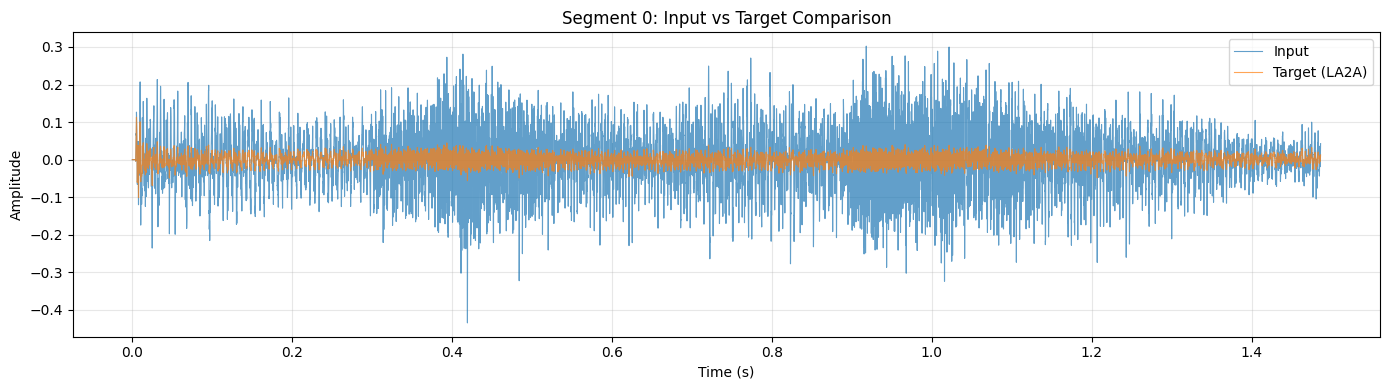

In [20]:
# Overlay input and target for comparison
seg_idx = 0
input_seg, target_seg = dataset[seg_idx]

input_np = input_seg.numpy()
target_np = target_seg.numpy()
time_axis = np.arange(len(input_np)) / SAMPLE_RATE

fig, ax = plt.subplots(1, 1, figsize=(14, 4))
ax.plot(time_axis, input_np, label='Input', alpha=0.7, linewidth=0.8)
ax.plot(time_axis, target_np, label='Target (LA2A)', alpha=0.7, linewidth=0.8)
ax.set_title(f'Segment {seg_idx}: Input vs Target Comparison')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Spectrogram Visualization

In [21]:
# Compute spectrograms
seg_idx = 0
input_seg, target_seg = dataset[seg_idx]

input_np = input_seg.numpy()
target_np = target_seg.numpy()

# Compute STFT
n_fft = 2048
hop_length = 512

input_stft = librosa.stft(input_np, n_fft=n_fft, hop_length=hop_length)
target_stft = librosa.stft(target_np, n_fft=n_fft, hop_length=hop_length)

input_mag = np.abs(input_stft)
target_mag = np.abs(target_stft)

# Convert to dB
input_db = librosa.amplitude_to_db(input_mag, ref=np.max)
target_db = librosa.amplitude_to_db(target_mag, ref=np.max)

# Plot spectrograms
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

librosa.display.specshow(
    input_db, 
    sr=SAMPLE_RATE, 
    hop_length=hop_length, 
    x_axis='time', 
    y_axis='hz',
    ax=axes[0]
)
axes[0].set_title(f'Segment {seg_idx}: Input Spectrogram')
axes[0].set_ylabel('Frequency (Hz)')

librosa.display.specshow(
    target_db, 
    sr=SAMPLE_RATE, 
    hop_length=hop_length, 
    x_axis='time', 
    y_axis='hz',
    ax=axes[1]
)
axes[1].set_title(f'Segment {seg_idx}: Target Spectrogram (LA2A Processed)')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Frequency (Hz)')

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

## Statistics Summary

In [ ]:
# Compute statistics across all segments
all_input_rms = []
all_target_rms = []
all_input_peak = []
all_target_peak = []
all_differences = []

for idx in range(len(dataset)):
    input_seg, target_seg = dataset[idx]
    input_np = input_seg.numpy()
    target_np = target_seg.numpy()
    
    all_input_rms.append(np.sqrt(np.mean(input_np**2)))
    all_target_rms.append(np.sqrt(np.mean(target_np**2)))
    all_input_peak.append(np.max(np.abs(input_np)))
    all_target_peak.append(np.max(np.abs(target_np)))
    all_differences.append(np.sqrt(np.mean((input_np - target_np)**2)))

print("Statistics across all segments:")
print(f"  Number of segments: {len(dataset)}")
print(f"\nInput audio:")
print(f"  RMS - Mean: {np.mean(all_input_rms):.4f}, Std: {np.std(all_input_rms):.4f}")
print(f"  Peak - Mean: {np.mean(all_input_peak):.4f}, Max: {np.max(all_input_peak):.4f}")
print(f"\nTarget audio:")
print(f"  RMS - Mean: {np.mean(all_target_rms):.4f}, Std: {np.std(all_target_rms):.4f}")
print(f"  Peak - Mean: {np.mean(all_target_peak):.4f}, Max: {np.max(all_target_peak):.4f}")
print(f"\nDifference (RMSE):")
print(f"  Mean: {np.mean(all_differences):.4f}, Std: {np.std(all_differences):.4f}")